# **Scenario 1: Apriori using Groceries Dataset**
## **Roll No:** 24BAD102
## **Name:** SaiSanjay R

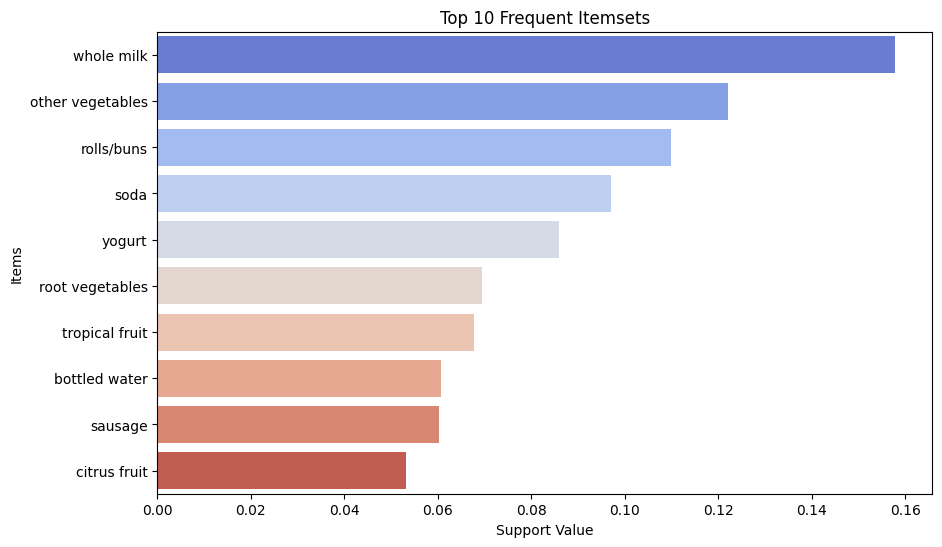

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


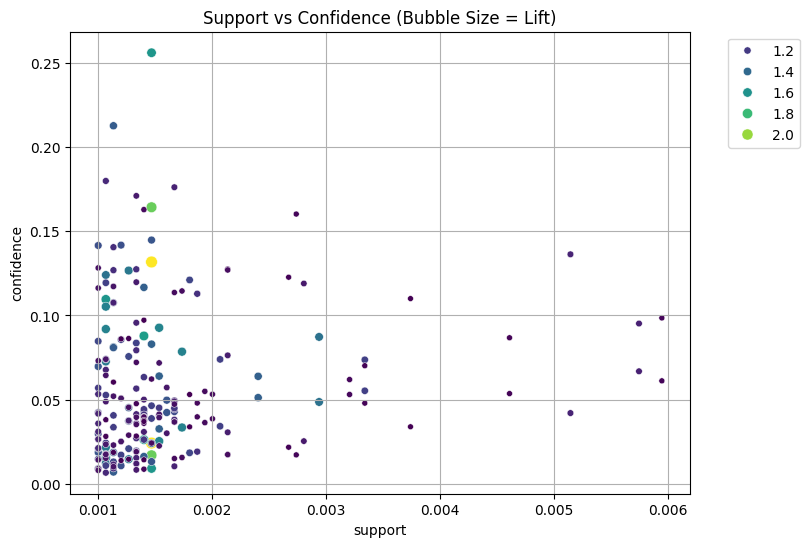

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

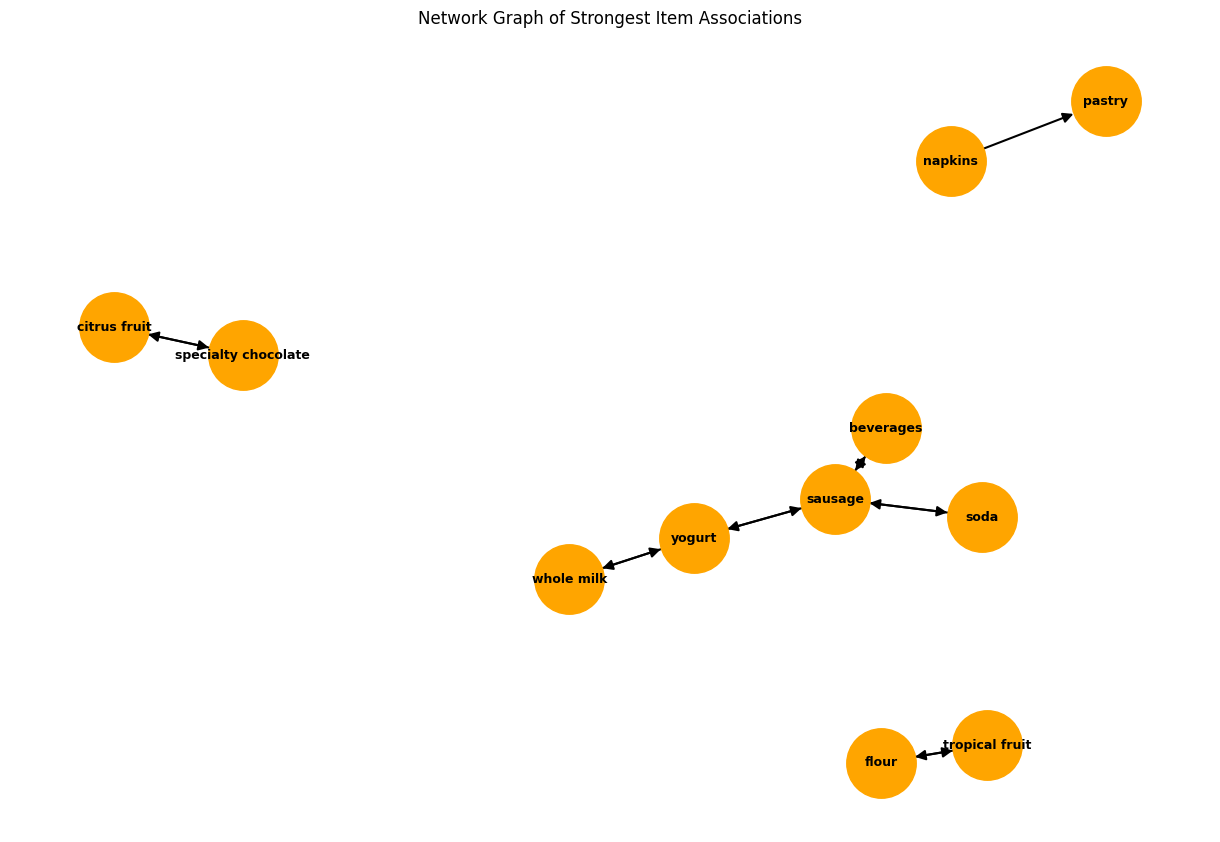

Total Transactions: 14963

Top 5 Frequent Itemsets:
      support            itemsets  length
146  0.157923        (whole milk)       1
90   0.122101  (other vegetables)       1
109  0.110005        (rolls/buns)       1
123  0.097106              (soda)       1
147  0.085879            (yogurt)       1

Strongest Association Rules (Sorted by Lift):
             antecedents            consequents   support  confidence  \
0              (sausage)   (yogurt, whole milk)  0.001470    0.024363   
1   (yogurt, whole milk)              (sausage)  0.001470    0.131737   
2  (sausage, whole milk)               (yogurt)  0.001470    0.164179   
3               (yogurt)  (sausage, whole milk)  0.001470    0.017121   
4         (citrus fruit)  (specialty chocolate)  0.001403    0.026415   
5  (specialty chocolate)         (citrus fruit)  0.001403    0.087866   
6      (yogurt, sausage)           (whole milk)  0.001470    0.255814   
7           (whole milk)      (yogurt, sausage)  0.001470    0.00

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 1. Load Transactional Dataset
df = pd.read_csv('Groceries_dataset.csv')

# 2. Data Preprocessing
# Group items by Member_number and Date to define a single transaction (basket)
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

# Convert to one-hot encoding format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

# 3. Generate Frequent Itemsets
# 5. Set minimum support threshold (0.001 is a common starting point for this large dataset)
min_support = 0.001
frequent_itemsets = apriori(df_onehot, min_support=min_support, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# 4 & 6. Generate Association Rules
# 7. Filter rules using confidence and lift
# We use a low confidence threshold (e.g., 0.05) because grocery baskets are diverse
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

# --- VISUALIZATIONS ---

# Task: Bar chart of frequent itemsets (Top 10)
plt.figure(figsize=(10, 6))
top_10_items = frequent_itemsets.sort_values('support', ascending=False).head(10)
top_10_items['itemsets_label'] = top_10_items['itemsets'].apply(lambda x: ', '.join(list(x)))
sns.barplot(x='support', y='itemsets_label', data=top_10_items, palette='coolwarm')
plt.title('Top 10 Frequent Itemsets')
plt.xlabel('Support Value')
plt.ylabel('Items')
plt.show()

# Task: Support vs Confidence Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=rules, palette='viridis')
plt.title('Support vs Confidence (Bubble Size = Lift)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Task: Network graph of association rules (Top 15 rules by Lift)
plt.figure(figsize=(12, 8))
G = nx.DiGraph()

# Select top rules for clarity in the graph
top_rules = rules.head(15)
for i in range(len(top_rules)):
    # Take first item from frozen sets for simple visualization
    ant = list(top_rules.iloc[i]['antecedents'])[0]
    cons = list(top_rules.iloc[i]['consequents'])[0]
    G.add_edge(ant, cons, weight=top_rules.iloc[i]['lift'])

pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='orange', node_size=2500,
        edge_color='black', font_size=9, font_weight='bold',
        width=1.5, arrows=True, arrowstyle='-|>', arrowsize=15)
plt.title('Network Graph of Strongest Item Associations')
plt.show()

# --- Display Results ---
print(f"Total Transactions: {len(transactions)}")
print("\nTop 5 Frequent Itemsets:")
print(frequent_itemsets.sort_values('support', ascending=False).head())

print("\nStrongest Association Rules (Sorted by Lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))